In [1]:
import numpy as np
import pandas as pd

from skimage import io
from skimage.measure import regionprops_table
from scipy.ndimage import generate_binary_structure, grey_erosion

from MEDUSSA.utils import BorderRemoval
from MEDUSSA.transform import ConfIntSampler
from MEDUSSA.measure import SizeDataFrame
from cellpose_omni.metrics import average_precision

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene,f_oneway,kruskal,tukey_hsd

from glob import glob

footprint = generate_binary_structure(2, 1)
backgrounds = pd.read_csv('/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/backgrounds.csv').groupby(['Condition','Type']).mean().reset_index()

print(np.unique(backgrounds['Condition']))

raw_backgrounds = backgrounds[backgrounds['Type'] == 'Raw']
deconvolved_backgrounds = backgrounds[backgrounds['Type'] == 'Deconvolved']
restored_backgrounds = backgrounds[backgrounds['Type'] == 'Restored']

illuminations = ['0.010s\n10%','0.010s\n50%','0.025s\n10%','0.025s\n50%', #Noisy, i1, i2, i3
                 '0.050s\n10%','0.050s\n50%','0.100s\n10%','0.100s\n50%', #i4, i5, i6, i7
                 '0.100s\n100%','0.200s\n10%','0.200s\n50%','0.200s\n100%'] #i8, i9, i10, Target


['Noisy' 'Target' 'i1' 'i10' 'i2' 'i3' 'i4' 'i5' 'i6' 'i7' 'i8' 'i9']


In [2]:
def BenchMarkDF(target_path,gt_path,background_df,label='Target'):

    gt_names = sorted(glob(f'{gt_path}/*.tif'))

    bg = np.array(background_df[background_df['Condition']==label]['Mean'])[0]

    names = [gt.split('/')[-1].replace('.tif','') for gt in gt_names]    

    gt_masks = []
    target_masks = []
    imgs = []

    SNRs = []
    
    for i,n in enumerate(names):

        target = sorted(glob(f'{target_path}/{n}*'))

        if len(target) == 1:

            gtmasks = BorderRemoval(io.imread(gt_names[i]))
        
            target_masks.append(BorderRemoval(io.imread(target[0])))
            gt_masks.append(gtmasks)
            
            img = io.imread(target[0].replace('masks/','').replace('_cp_masks.png','.tif'))
    
            contours = gtmasks - grey_erosion(gtmasks,footprint=footprint)
    
            mean_signal = regionprops_table(label_image=contours,intensity_image=img,properties=['intensity_mean'])['intensity_mean'].mean()
    
            SNRs.append(mean_signal/bg)
            
    JI, tp, fp, fn = average_precision(gt_masks,target_masks,threshold=[0.8])
    f1 = 2*tp/(2*tp+fn+fp)
    
    df = pd.DataFrame()
    
    f1_ = [f[0] for f in f1]
    
    df.insert(0,'F1 score',f1_)
    df.insert(0,'Illumination',label)
    df.insert(2,'SNR',SNRs)
    
    return df

In [3]:
### Deconvolved images

gt_path = '/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Benchmarking_masks/masks/'

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

deconvolved_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/For_benchmarking/{f}/masks/'
   
    df = BenchMarkDF(target_path=target_path,gt_path=gt_path,label=f,background_df=deconvolved_backgrounds)

    exposure,transmission = illuminations[i].split('\n')

    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)
    
    deconvolved_dfs.append(df)

full_df_deconvolved = pd.concat(deconvolved_dfs,ignore_index=True)


/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered 

In [4]:
### RESTORED IMAGES

gt_path = '/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/Benchmarking_masks/masks/'

folders = ['Noisy','i1','i2','i3','i4','i5','i6','i7','i8','i9','i10','Target']

restored_dfs = []

for i,f in enumerate(folders):

    target_path = f'/Users/reyesmatte/Desktop/copypasta/FM_benchmarking_intensities/CARE_predictions/{f}/masks/'
   
    df = BenchMarkDF(target_path=target_path,gt_path=gt_path,label=f,background_df=restored_backgrounds)

    exposure,transmission = illuminations[i].split('\n')

    df.insert(1,'Exposure time',exposure)
    df.insert(2,'Light transmission',transmission)
    
    restored_dfs.append(df)

full_df_restored = pd.concat(restored_dfs,ignore_index=True)

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered in divide
  iou = overlap / (n_pixels_pred + n_pixels_true - overlap)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/cellpose_omni/metrics.py:205: RuntimeWarning: invalid value encountered 

In [10]:
full_df_deconvolved.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS13_deconvolved_data.csv')
full_df_restored.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS13_restored_data.csv')

In [6]:
full_df_deconvolved = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS13_deconvolved_data.csv')
full_df_restored = pd.read_csv('https://github.com/OReyesMatte/MEDUSSA/raw/refs/heads/main/Raw_Data/FigS13_restored_data.csv')

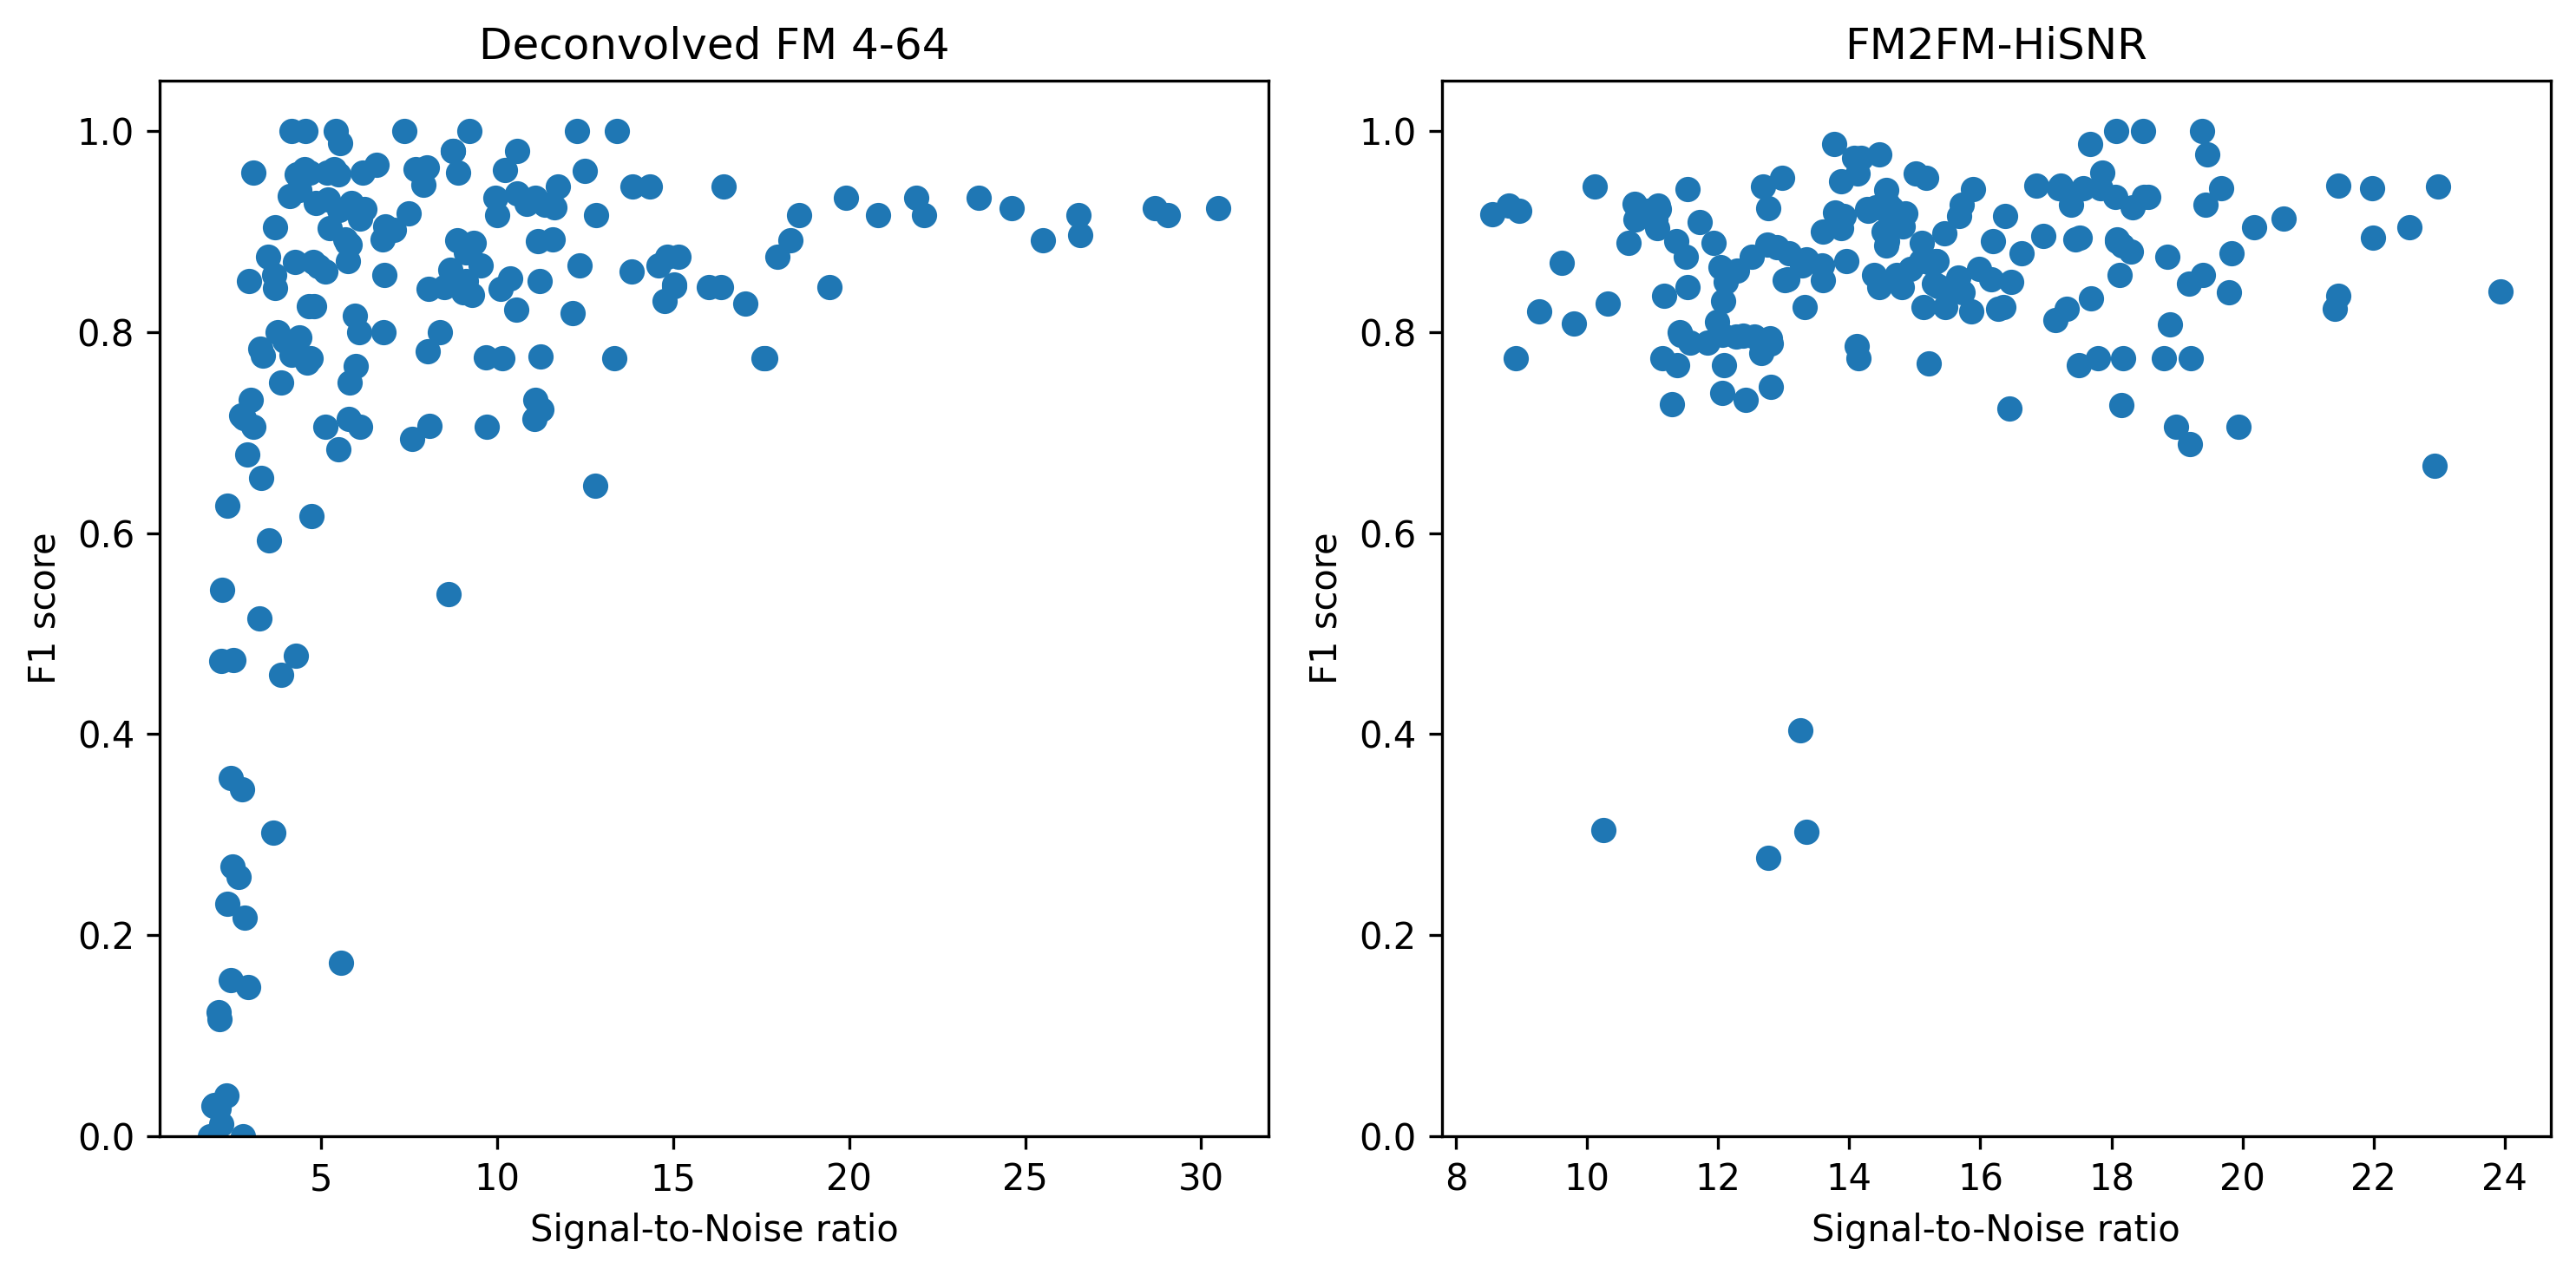

In [7]:
fig,ax = plt.subplots(dpi=300,figsize=(10,5),ncols=2)

ax[0].scatter(full_df_deconvolved['SNR'],full_df_deconvolved['F1 score'])
ax[0].set_xlabel('Signal-to-Noise ratio')
ax[0].set_ylabel('F1 score')
ax[0].set_ylim(0,1.05)
ax[0].set_title('Deconvolved FM 4-64')

ax[1].scatter(full_df_restored['SNR'],full_df_restored['F1 score'])
ax[1].set_xlabel('Signal-to-Noise ratio')
ax[1].set_ylabel('F1 score')
ax[1].set_ylim(0,1.05)
ax[1].set_title('FM2FM-HiSNR')

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS13/F1_vs_SNR.png')